In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import scipy as sp
import scipy.io.wavfile as wf
import librosa
import librosa.display
import IPython.display as ipd
import os
import soundfile as sf
import lightgbm
%matplotlib inline
from itertools import cycle
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from keras.regularizers import l2
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from sklearn.preprocessing import scale
import warnings
import random
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

np.random.seed(4)

In [2]:
train_df = pd.read_csv('development.csv')
train_df['path'] = 'D:/Data Science and Engineering/Datasets/' + train_df['path']

In [3]:
train_df['intention'] = train_df.pop('action') + train_df.pop('object')

In [4]:
train_df.drop(['Id' , 'speakerId'], axis=1, inplace=True)
train_df.drop(['Self-reported fluency level ', 'First Language spoken', 'Current language used for work/school'], axis=1, inplace=True)
train_df.drop(['gender', 'ageRange'], axis=1, inplace=True)

In [5]:
def get_audio_duration(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)
        return librosa.get_duration(y=y, sr=sr)
    except Exception as e:
        print(f"Failed on {file_path}: {e}")
        return None

train_df["duration"] = train_df["path"].apply(get_audio_duration)

c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


In [6]:
z_score = np.abs(stats.zscore(train_df['duration']))

In [7]:
print(train_df.shape)

clean_df = train_df[z_score<3]
clean_df.shape

(9854, 3)


(9553, 3)

In [8]:
clean_df.loc[:, 'intention'] = clean_df['intention'].replace('change languagenone', 'changelanguage')

In [9]:
audiopath = clean_df['path'].tolist()

In [10]:
import librosa
import numpy as np
from tqdm import tqdm

DBT = []
mfccs = []

target_length = 231525  # 10.5 sec @ 22050 Hz
top_db = 20             # Silence threshold
n_mfcc = 40             # Number of MFCCs
hop_length = 512
n_fft = 2048
fixed_T = (target_length - n_fft) // hop_length + 1  # This ensures consistent MFCC width

for path in tqdm(audiopath, desc="Processing Audio"):
    # Load audio
    x, sr = librosa.load(path, sr=None)

    # Get duration before trimming
    duration_before_trim = len(x) / sr

    # Trim silence
    trimmed_audio, _ = librosa.effects.trim(x, top_db=top_db)

    # Pad or truncate audio to fixed sample length
    processed_audio = librosa.util.fix_length(trimmed_audio, size=target_length)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=processed_audio, sr=sr, n_mfcc=n_mfcc,
                                hop_length=hop_length, n_fft=n_fft)

    # Pad or truncate time axis to fixed_T
    if mfcc.shape[1] < fixed_T:
        pad_width = fixed_T - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :fixed_T]

    # Save duration and MFCC
    DBT.append(duration_before_trim)
    mfccs.append(mfcc)

Processing Audio: 100%|██████████| 9553/9553 [03:19<00:00, 48.00it/s]


In [11]:
feature= np.array(mfccs)
feature.shape

(9553, 40, 449)

In [12]:
feature= feature.reshape(feature.shape[0], -1)
x= feature
y= clean_df['intention']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=True, random_state=4, stratify=y)

In [14]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
X_train_res = X_train_scaled.reshape(-1, 40, 449, 1)  # CNN expects 4D
X_test_scaled = X_test_scaled.reshape(-1, 40, 449, 1)

print(X_train_res.shape)
print(X_test_scaled.shape)

(7642, 40, 449, 1)
(1911, 40, 449, 1)


In [18]:
encoder = LabelEncoder()

y_train_cat = to_categorical(encoder.fit_transform(y_train), num_classes=7)
y_test_cat = to_categorical(encoder.transform(y_test), num_classes=7)

In [21]:
y_test_cat

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [20]:
x_train = X_train_res.astype('float32')
x_test = X_test_scaled.astype('float32') 

In [19]:
y_train_cat.shape

(7642, 7)

In [ ]:
input_shape = X_train_res.shape[1:]
weight_decay = 1e-4       # L2 regularization strength
dropout_rate = 0.4        # Dropout fraction
initial_lr = 1e-3         # Initial learning rate

# Build a deeper CNN with BatchNorm and L2 regularization
model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 2nd Convolutional Block
model.add(Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 3rd Convolutional Block (optional, for deeper feature learning)
model.add(Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# Flatten and Dense Layers
model.add(Flatten())
model.add(Dense( 256, activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# Output Layer
model.add(Dense(y_train_cat.shape[1], activation='softmax'))

# Compile with Adam optimizer (adjust learning rate as needed)
optimizer = Adam(learning_rate=initial_lr)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()

# Callbacks: ReduceLROnPlateau & EarlyStopping
# reduce LR by half
# wait 3 epochs with no improvement
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(x_train, y_train_cat, epochs=20, batch_size=32, validation_split=0.2 ,validation_data=(x_test, y_test_cat), callbacks=[reduce_lr, early_stopping])

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 38, 447, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 38, 447, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 19, 223, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 19, 223, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 17, 221, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 17, 221, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 110, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 110, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 6, 108, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 6, 108, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 3, 54, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 3, 54, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,405,063 (20.62 MB)

 Trainable params: 5,404,103 (20.62 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 269s 597ms/step - accuracy: 0.1778 - loss: 2.6824 - val_accuracy: 0.1062 - val_loss: 9.6444 - learning_rate: 0.0010
Epoch 2/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 267s 597ms/step - accuracy: 0.3116 - loss: 1.8328 - val_accuracy: 0.2402 - val_loss: 2.0807 - learning_rate: 0.0010
Epoch 3/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 244s 547ms/step - accuracy: 0.4000 - loss: 1.6351 - val_accuracy: 0.1533 - val_loss: 3.6085 - learning_rate: 0.0010
Epoch 4/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 242s 540ms/step - accuracy: 0.4309 - loss: 1.5562 - val_accuracy: 0.2276 - val_loss: 2.4028 - learning_rate: 0.0010
Epoch 5/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.4638 - loss: 1.4895
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
447/447 ━━━━━━━━━━━━━━━━━━━━ 237s 530ms/step - accuracy: 0.4638 - loss: 1.4895 - val_accuracy: 0.0801 - val_loss: 190.2979 - learning_rate: 0.0010
Epoch 6/20
447/447 ━━━━━━━━━━━━━━━━━━━━ 241s 540ms/step - accurac

In [ ]:
loss, acc = model.evaluate(x_test, y_test_cat)

In [21]:
input_shape = X_train_res.shape[1:]
weight_decay = 1e-3        # L2 regularization strength
dropout_rate = 0.45        # Dropout fraction
initial_lr = 5e-4         # Initial learning rate

# Build a deeper CNN with BatchNorm and L2 regularization
model = Sequential()

# 1st Block
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape, kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 2nd Block
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 3rd Block
model.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# Dense Layers
model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# Output Layer
model.add(Dense(y_train_cat.shape[1], activation='softmax'))

# Compile with Adam optimizer (adjust learning rate as needed)
optimizer = Adam(learning_rate=initial_lr)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()

# Callbacks: ReduceLROnPlateau & EarlyStopping
# reduce LR by half
# wait 3 epochs with no improvement
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history = model.fit(X_train_res, y_train_cat, epochs=30, batch_size=16, validation_data=(X_test_scaled, y_test_cat), callbacks=[reduce_lr, early_stopping])

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 40, 449, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 449, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 224, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 224, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 224, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 224, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 112, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 112, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 112, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 112, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 56, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 56, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 35840)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,175,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,271,687 (35.37 MB)

 Trainable params: 9,270,727 (35.37 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/30
894/894 ━━━━━━━━━━━━━━━━━━━━ 430s 477ms/step - accuracy: 0.2042 - loss: 3.4113 - val_accuracy: 0.1659 - val_loss: 4.0935 - learning_rate: 5.0000e-04
Epoch 2/30
894/894 ━━━━━━━━━━━━━━━━━━━━ 348s 389ms/step - accuracy: 0.3751 - loss: 2.3036 - val_accuracy: 0.1355 - val_loss: 7.7369 - learning_rate: 5.0000e-04
Epoch 3/30
894/894 ━━━━━━━━━━━━━━━━━━━━ 352s 394ms/step - accuracy: 0.4201 - loss: 2.0915 - val_accuracy: 0.1675 - val_loss: 3.0281 - learning_rate: 5.0000e-04
Epoch 4/30
894/894 ━━━━━━━━━━━━━━━━━━━━ 354s 395ms/step - accuracy: 0.4367 - loss: 2.0046 - val_accuracy: 0.1732 - val_loss: 6.8929 - learning_rate: 5.0000e-04
Epoch 5/30
894/894 ━━━━━━━━━━━━━━━━━━━━ 350s 392ms/step - accuracy: 0.4704 - loss: 2.0198 - val_accuracy: 0.2308 - val_loss: 28.0041 - learning_rate: 5.0000e-04
Epoch 6/30
894/894 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.4933 - loss: 2.0861
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
894/894 ━━━━━━━━━━━━━━━━━━━━ 360s 4

KeyboardInterrupt: 

In [19]:
input_shape = X_train_res.shape[1:]

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(y_train_cat.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
history = model.fit(X_train_res, y_train_cat, epochs=10, batch_size=32, validation_data=(X_test_scaled, y_test_cat))

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 114s 251ms/step - accuracy: 0.1466 - loss: 1.9911 - val_accuracy: 0.1648 - val_loss: 1.9310
Epoch 2/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 118s 264ms/step - accuracy: 0.2148 - loss: 1.8969 - val_accuracy: 0.2643 - val_loss: 1.7727
Epoch 3/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 115s 258ms/step - accuracy: 0.3929 - loss: 1.5773 - val_accuracy: 0.3590 - val_loss: 1.5748
Epoch 4/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 127s 285ms/step - accuracy: 0.4616 - loss: 1.4044 - val_accuracy: 0.3977 - val_loss: 1.4486
Epoch 5/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 124s 277ms/step - accuracy: 0.4850 - loss: 1.3340 - val_accuracy: 0.3883 - val_loss: 1.4769
Epoch 6/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 121s 272ms/step - accuracy: 0.5067 - loss: 1.2885 - val_accuracy: 0.3972 - val_loss: 1.4990
Epoch 7/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 119s 267ms/step - accuracy: 0.5285 - loss: 1.2323 - val_accuracy: 0.4218 - val_loss: 1.4274
Epoch 8/10
447/447 ━━━━━━━━━━━━━━━━━━━━ 116s 260ms/step - accuracy: 0.5434 -

In [20]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# Plot the training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

ValueError: Invalid dtype: object

In [11]:
input_shape = X_train.shape[1:]

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(y_train.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 11, 126, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 63, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 63, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 61, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 30, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 30, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 265,607 (1.01 MB)

 Trainable params: 265,607 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2138 - loss: 1.9033 - val_accuracy: 0.2014 - val_loss: 1.8225
Epoch 2/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3972 - loss: 1.5684 - val_accuracy: 0.3440 - val_loss: 1.6060
Epoch 3/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.4949 - loss: 1.3201 - val_accuracy: 0.4084 - val_loss: 1.4760
Epoch 4/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5562 - loss: 1.1597 - val_accuracy: 0.4231 - val_loss: 1.4139
Epoch 5/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5992 - loss: 1.0547 - val_accuracy: 0.4094 - val_loss: 1.4408
Epoch 6/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6336 - loss: 0.9692 - val_accuracy: 0.4510 - val_loss: 1.3898
Epoch 7/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6602 - loss: 0.8936 - val_accuracy: 0.4373 - val_loss: 1.3791
Epoch 8/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6810 - loss: 0.8444 - val_accu

KeyboardInterrupt: 

In [ ]:
input_shape = X_train.shape[1:]
weight_decay = 1e-4
dropout_rate = 0.4

model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(weight_decay)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(Dropout(dropout_rate))
model.add(Dense(y_train.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Early stopping callback
# Stop if val_loss doesn't improve for 5 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stopping])

c:\Users\ASUS\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21504)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,752,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,772,359 (10.58 MB)

 Trainable params: 2,772,359 (10.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.1625 - loss: 3.6707 - val_accuracy: 0.1644 - val_loss: 1.9568
Epoch 2/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.2293 - loss: 1.8824 - val_accuracy: 0.2998 - val_loss: 1.7210
Epoch 3/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.3732 - loss: 1.6131 - val_accuracy: 0.4023 - val_loss: 1.5028
Epoch 4/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.4330 - loss: 1.4557 - val_accuracy: 0.4394 - val_loss: 1.4482
Epoch 5/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.4955 - loss: 1.3296 - val_accuracy: 0.4876 - val_loss: 1.3044
Epoch 6/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 40s 87ms/step - accuracy: 0.5314 - loss: 1.2338 - val_accuracy: 0.4845 - val_loss: 1.3170
Epoch 7/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 90ms/step - accuracy: 0.5700 - loss: 1.1565 - val_accuracy: 0.5079 - val_loss: 1.2570
Epoch 8/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 41s 89ms/step - accuracy: 0.5996 - loss: 1.1078 - 

In [ ]:
# Example hyperparameters you can tune
input_shape = X_train.shape[1:]
weight_decay = 1e-4       # L2 regularization strength
dropout_rate = 0.4        # Dropout fraction
initial_lr = 1e-3         # Initial learning rate

# Build a deeper CNN with BatchNorm and L2 regularization
model = Sequential()

# 1st Convolutional Block
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 2nd Convolutional Block
model.add(Conv2D( 64, (3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 3rd Convolutional Block (optional, for deeper feature learning)
model.add(Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# Flatten and Dense Layers
model.add(Flatten())
model.add(Dense( 256, activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# Output Layer
model.add(Dense(y_train_balanced.shape[1], activation='softmax'))

# Compile with Adam optimizer (adjust learning rate as needed)
optimizer = Adam(learning_rate=initial_lr)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()

# Callbacks: ReduceLROnPlateau & EarlyStopping
# reduce LR by half
# wait 3 epochs with no improvement
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 38, 172, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 38, 172, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 19, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 17, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 17, 84, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 42, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 6, 40, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 6, 40, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 3, 20, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 7680)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     1,966,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,062,727 (7.87 MB)

 Trainable params: 2,061,767 (7.87 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=[reduce_lr, early_stopping])

Epoch 1/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 106s 224ms/step - accuracy: 0.2859 - loss: 2.1760 - val_accuracy: 0.1497 - val_loss: 3.2753 - learning_rate: 0.0010
Epoch 2/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 95s 207ms/step - accuracy: 0.4968 - loss: 1.3907 - val_accuracy: 0.2740 - val_loss: 2.7503 - learning_rate: 0.0010
Epoch 3/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 95s 207ms/step - accuracy: 0.5792 - loss: 1.1669 - val_accuracy: 0.3572 - val_loss: 2.3515 - learning_rate: 0.0010
Epoch 4/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 101s 219ms/step - accuracy: 0.6175 - loss: 1.0586 - val_accuracy: 0.3349 - val_loss: 2.6856 - learning_rate: 0.0010
Epoch 5/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 108s 235ms/step - accuracy: 0.6523 - loss: 1.0060 - val_accuracy: 0.4333 - val_loss: 2.2603 - learning_rate: 0.0010
Epoch 6/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 102s 222ms/step - accuracy: 0.6775 - loss: 0.9527 - val_accuracy: 0.5606 - val_loss: 1.2842 - learning_rate: 0.0010
Epoch 7/20
460/460 ━━━━━━━━━━━━━━━━━━━━ 100s 218ms/step - accuracy

In [20]:
# Example hyperparameters you can tune
input_shape = X_train.shape[1:]
weight_decay = 1e-3        # L2 regularization strength
dropout_rate = 0.45        # Dropout fraction
initial_lr = 5e-4         # Initial learning rate

# Build a deeper CNN with BatchNorm and L2 regularization
model = Sequential()

# 1st Block
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape, kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 2nd Block
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# 3rd Block
model.add(Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(dropout_rate))

# Dense Layers
model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(weight_decay)))
model.add(BatchNormalization())
model.add(Dropout(dropout_rate))

# Output Layer
model.add(Dense(y_train.shape[1], activation='softmax'))

# Compile with Adam optimizer (adjust learning rate as needed)
optimizer = Adam(learning_rate=initial_lr)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

model.summary()

# Callbacks: ReduceLROnPlateau & EarlyStopping
# reduce LR by half
# wait 3 epochs with no improvement
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 13, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 13, 128, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 64, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 6, 64, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 6, 64, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 6, 64, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 3, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 3, 32, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 3, 32, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 3, 32, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 1, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,935 (2.37 MB)

 Trainable params: 619,975 (2.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [21]:
history = model.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test), callbacks=[reduce_lr, early_stopping])

Epoch 1/30
735/735 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.1988 - loss: 3.1468 - val_accuracy: 0.1262 - val_loss: 4.1676 - learning_rate: 5.0000e-04
Epoch 2/30
735/735 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.2931 - loss: 2.4962 - val_accuracy: 0.1712 - val_loss: 3.6632 - learning_rate: 5.0000e-04
Epoch 3/30
735/735 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3359 - loss: 2.3016 - val_accuracy: 0.1712 - val_loss: 2.7788 - learning_rate: 5.0000e-04
Epoch 4/30
735/735 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.3870 - loss: 2.1443 - val_accuracy: 0.2010 - val_loss: 2.7804 - learning_rate: 5.0000e-04
Epoch 5/30
735/735 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.4319 - loss: 1.9844 - val_accuracy: 0.2245 - val_loss: 2.5690 - learning_rate: 5.0000e-04
Epoch 6/30
735/735 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.4452 - loss: 1.9135 - val_accuracy: 0.2657 - val_loss: 2.2871 - learning_rate: 5.0000e-04
Epoch 7/30
735/735 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/ste

Test loss: 0.9456192255020142
Test accuracy: 0.7757483720779419


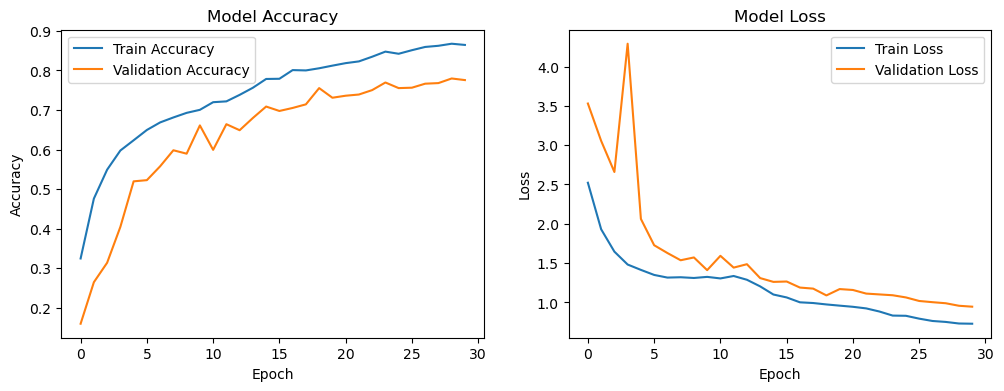

In [15]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# Plot the training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()